In [1]:
!pip install gymnasium

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt

In [27]:
class ParcelDeliveryEnv(gym.Env):
    def __init__(self):
        super(ParcelDeliveryEnv, self).__init__()
        #The grid size is 5*5
        self.grid_rows = 5
        self.grid_cols = 5

        #actions 0 up, 1 down, 2 left, 3 right
        self.action_space = spaces.Discrete(4)

        #observation is a single integer state from 0 to 24
        self.observation_space = spaces.Discrete(self.grid_rows * self.grid_cols)

        #starting point of the drone
        self.start_pos = np.array([0, 0])
        self.drone_pos = self.start_pos.copy()

        #important map locations
        self.parcel_location = np.array([2, 2])
        self.delivery_house = np.array([0, 3])

        #hazard areas to watch out
        self.wind_zones = [np.array([4, 1]), np.array([2, 4])]
        self.no_fly_zone = np.array([4, 3])
        self.low_battery_zone = np.array([3, 1])

        #parcel flag
        self.has_parcel = False


    def reset(self, seed=None, options=None):
        # reset position and parcel status
        self.drone_pos = self.start_pos.copy()
        self.has_parcel = False
        state = self._pos_to_state(self.drone_pos)
        return state, {}


    def step(self, action):
        # move based on action
        if action == 0:
            self.drone_pos[1] += 1
        elif action == 1:
            self.drone_pos[1] -= 1
        elif action == 2:
            self.drone_pos[0] -= 1
        elif action == 3:
            self.drone_pos[0] += 1

        # keep inside grid area
        self.drone_pos[0] = np.clip(self.drone_pos[0], 0, self.grid_cols - 1)
        self.drone_pos[1] = np.clip(self.drone_pos[1], 0, self.grid_rows - 1)
        reward = -1
        terminated = False

        # pick parcel
        if np.array_equal(self.drone_pos, self.parcel_location) and not self.has_parcel:
            self.has_parcel = True
            reward += 10

        #hazard penalties
        if any(np.array_equal(self.drone_pos, w) for w in self.wind_zones):
            reward -= 10

        if np.array_equal(self.drone_pos, self.low_battery_zone):
            reward -= 5

        if np.array_equal(self.drone_pos, self.no_fly_zone):
            reward -= 15

        #delivery
        if np.array_equal(self.drone_pos, self.delivery_house) and self.has_parcel:
            reward += 25
            terminated = True

        state = self._pos_to_state(self.drone_pos)
        return state, reward, terminated, False, {}


    def render(self):
        #creating grid text map
        grid = np.zeros((self.grid_rows, self.grid_cols), dtype=object)
        for r in range(self.grid_rows):
            for c in range(self.grid_cols):
                grid[r, c] = " . "

        #mark special zones
        grid[self.parcel_location[1], self.parcel_location[0]] = " PK "
        grid[self.delivery_house[1], self.delivery_house[0]] = " DH "

        for wz in self.wind_zones:
            grid[wz[1], wz[0]] = " WZ "

        grid[self.no_fly_zone[1], self.no_fly_zone[0]] = " NF "
        grid[self.low_battery_zone[1], self.low_battery_zone[0]] = " LB "

        #mark drone
        grid[self.drone_pos[1], self.drone_pos[0]] = " DR "

        #draw grid with matplotlib
        plt.figure(figsize=(6, 6))
        plt.imshow(np.zeros((self.grid_rows, self.grid_cols)), cmap="gray_r")
        plt.xticks(range(self.grid_cols))
        plt.yticks(range(self.grid_rows))
        plt.grid(True)

        for r in range(self.grid_rows):
            for c in range(self.grid_cols):
                plt.text(c, r, grid[r, c], ha="center", va="center", fontsize=15)

        plt.title("Parcel Delivery Drone Grid World")
        plt.show()


    def _pos_to_state(self, pos):
        #convert xy to state number
        return pos[1] * self.grid_cols + pos[0]

Finally, it was checked that the environment logic behaves correctly by running a random agent for 10 timesteps.
At every step, the code prints:

the current state

the action chosen

the reward received

the next state

and it also displays the full grid visualization.

This random agent moved safely inside the grid boundaries, picked up reward signals when entering special tiles, and received penalties in hazard zones-all confirming that the environment rules work as expected.

The environment is a 5 × 5 grid, giving 25 total states.

A state is an integer from 0 to 24 that has been mapped from a position in the drone’s coordinates, (x, y).

Actions

The agent has 4 possible actions:

0 - move up

1 - move down

2 - move left

3 - move right

Invalid moves trying to go outside the grid are clipped to keep the drone inside the map.

Rewards

Reward system: encourages the pickup and delivery of parcels while discouraging risky zones.

+10 - picking up the parcel

+25 - delivering the parcel at the delivery house

–1 - per step (time cost)

-10 - Entering a wind zone

-15 - entry into a no-fly zone

–5 - entering a low-battery zone

Main Objective

The goal of the drone is:

Starting in the default position
Move to where the parcel is and pick it up
Get around safely Deliver the parcel to the delivery house while collecting maximum reward This creates a classic grid-world MDP with hazards, positive goals, and meaningful navigation.

Initial State: 0


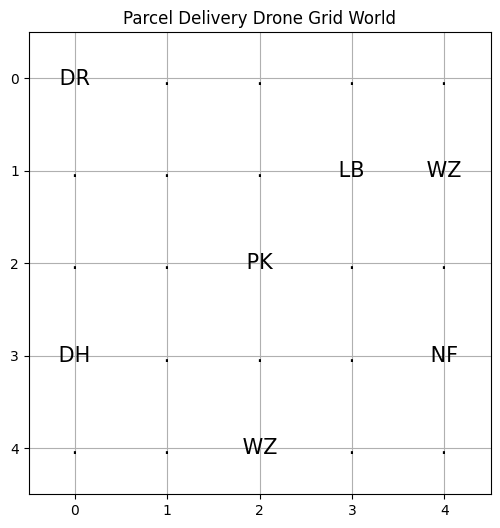

In [28]:
env = ParcelDeliveryEnv()
state, _ = env.reset()
print("Initial State:", state)

env.render()


Running 10-step random agent

Step: 1
State: 0
Action: 3
Reward: -1
Next State: 1
----------------------------------------------------------------------------------------------------


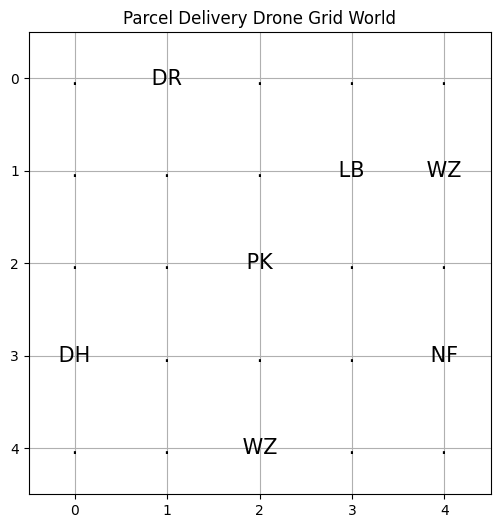

Step: 2
State: 1
Action: 2
Reward: -1
Next State: 0
----------------------------------------------------------------------------------------------------


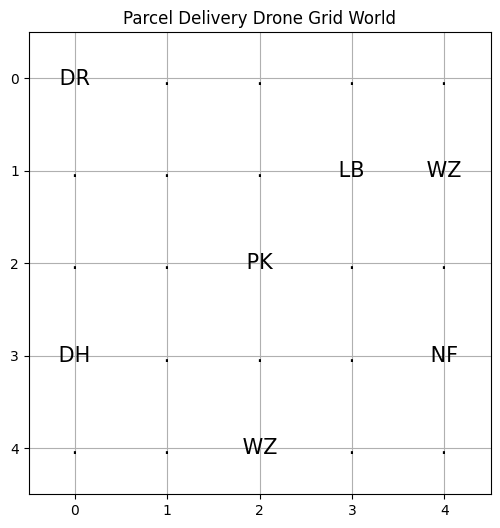

Step: 3
State: 0
Action: 3
Reward: -1
Next State: 1
----------------------------------------------------------------------------------------------------


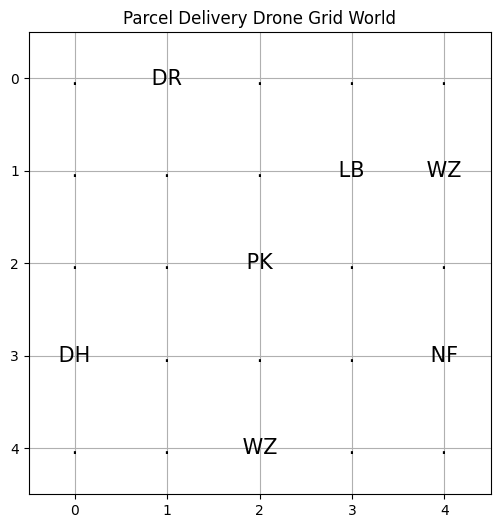

Step: 4
State: 1
Action: 1
Reward: -1
Next State: 1
----------------------------------------------------------------------------------------------------


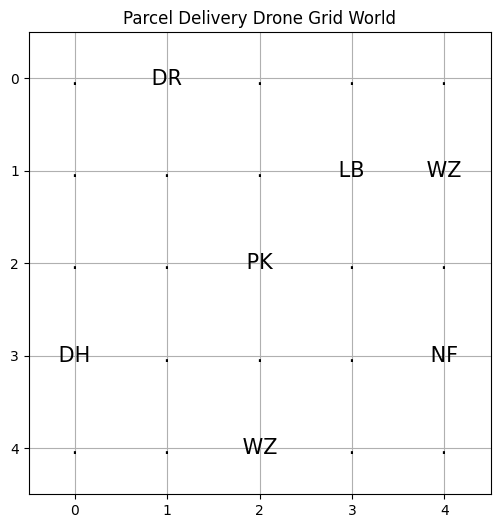

Step: 5
State: 1
Action: 2
Reward: -1
Next State: 0
----------------------------------------------------------------------------------------------------


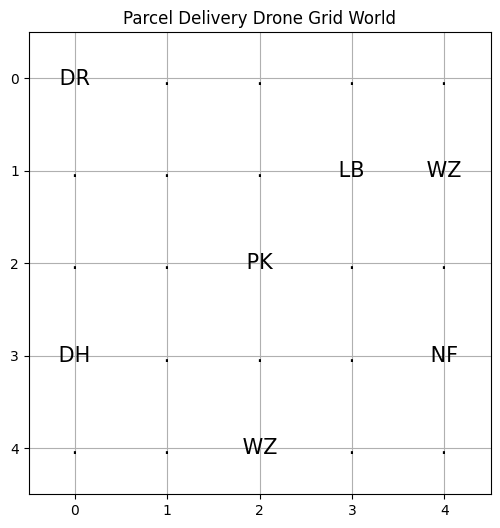

Step: 6
State: 0
Action: 2
Reward: -1
Next State: 0
----------------------------------------------------------------------------------------------------


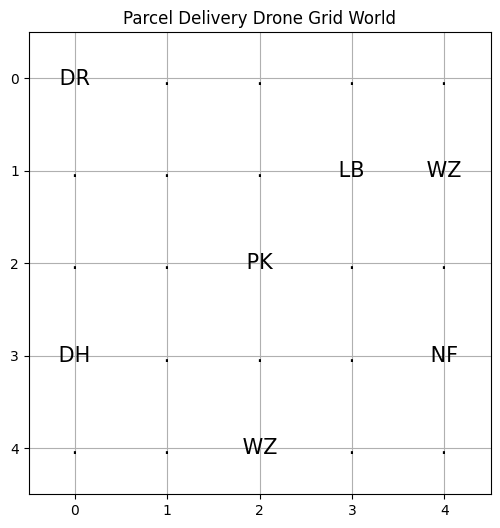

Step: 7
State: 0
Action: 2
Reward: -1
Next State: 0
----------------------------------------------------------------------------------------------------


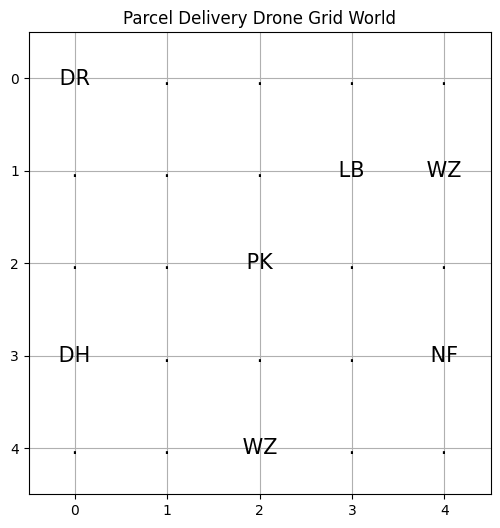

Step: 8
State: 0
Action: 2
Reward: -1
Next State: 0
----------------------------------------------------------------------------------------------------


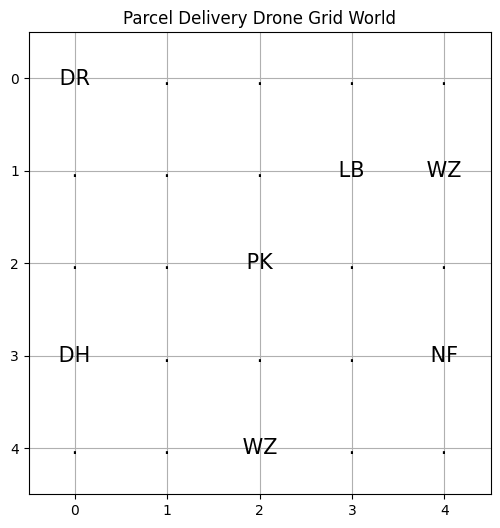

Step: 9
State: 0
Action: 2
Reward: -1
Next State: 0
----------------------------------------------------------------------------------------------------


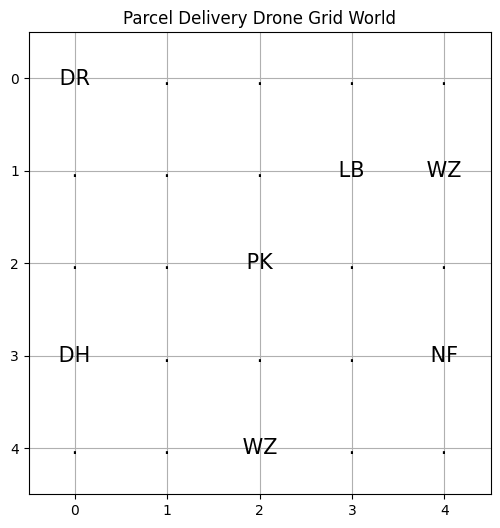

Step: 10
State: 0
Action: 0
Reward: -1
Next State: 5
----------------------------------------------------------------------------------------------------


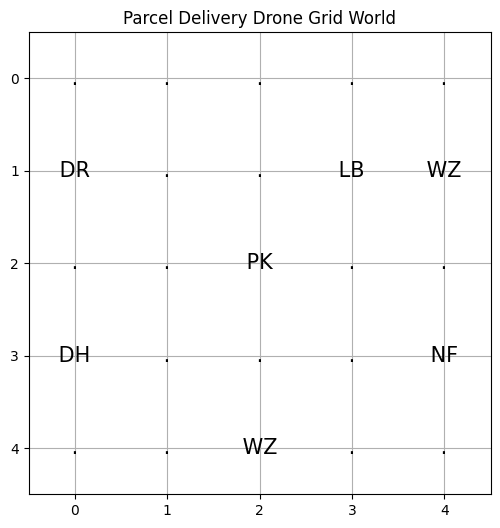

In [29]:
state, _ = env.reset()

print("Running 10-step random agent\n")

for step in range(10):
    action = env.action_space.sample()
    next_state, reward, done, _, _ = env.step(action)

    print("Step:", step + 1)
    print("State:", state)
    print("Action:", action)
    print("Reward:", reward)
    print("Next State:", next_state)
    print("-"*100)

    env.render()

    state = next_state

    if done:
        print("Parcel delivered successfully!")
        break

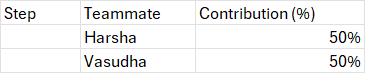